In [1]:
# Data taken from https://zenodo.org/records/6862671
from google.colab import drive
drive.mount('/content/drive')
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import glob
train_data = []
for fn in glob.glob('/content/drive/MyDrive/MicCleaner/*/mics/*.npy', recursive=True):
   train_data.append({
       "image": fn,
       "annotation": fn.replace('/mics/', '/masks_proc/')
   })

In [3]:
import numpy as np
def random_k90_flip(img, mask, points=None, rng=None):
    """
    Apply the same random rotation by {0,90,180,270} and optional flip ('h' or 'v')
    to image, mask, and (optionally) points. No interpolation is used.
    """
    rng = np.random.default_rng() if rng is None else rng
    H, W = img.shape[:2]

    k = rng.integers(0, 4)             # rotation in quarter-turns CCW
    flip_axis = rng.choice(['none', 'h', 'v'])  # choose one axis or none

    # rotate
    img2  = np.rot90(img, k, axes=(0, 1))
    mask2 = np.rot90(mask, k)

    # flip
    if flip_axis != 'none':
        img2  = np.flip(img2, 1 if flip_axis=='h' else 0)
        mask2  = np.flip(mask2, 1 if flip_axis=='h' else 0)

    return img2, mask2

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from skimage.transform import resize

def read_entry(entry, out_size=512, do_aug=True):
    img = np.load(entry["image"])          # (H,W) grayscale (float or uint)
    msk = np.load(entry["annotation"]).astype(np.uint8)  # (H,W) 0/1

    if do_aug:
        img, msk = random_k90_flip(img, msk)

    # Normalize image to [0,1]
    img = img.astype(np.float32)
    minv, maxv = float(img.min()), float(img.max())
    if maxv > minv:
        img = (img - minv) / (maxv - minv)
    else:
        img = np.zeros_like(img, dtype=np.float32)

    # Resize
    img = resize(img, (out_size, out_size), order=1, anti_aliasing=True, preserve_range=True).astype(np.float32)
    msk = resize(msk, (out_size, out_size), order=0, anti_aliasing=False, preserve_range=True).astype(np.uint8)
    msk = (msk > 0).astype(np.uint8)

    # Replicate to 3 channels for ImageNet encoders
    img3 = np.stack([img, img, img], axis=0)   # (3,H,W)
    msk1 = msk[None, ...].astype(np.float32)   # (1,H,W) in {0,1}
    return img3, msk1

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

class MicCleanerDataset(Dataset):
    def __init__(self, items, out_size=512, augment=True):
        self.items = items
        self.out_size = out_size
        self.augment = augment

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        x, y = read_entry(self.items[idx], self.out_size, do_aug=self.augment)
        x = torch.from_numpy(x)           # float32, (3,H,W)
        y = torch.from_numpy(y)           # float32, (1,H,W)
        return x, y

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pin = (device.type == 'cuda')
full_ds = MicCleanerDataset(train_data, out_size=512, augment=True)
data_loader = DataLoader(full_ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=pin)


In [6]:
!pip -q install --upgrade pip
!pip -q install segmentation-models-pytorch

In [7]:
import segmentation_models_pytorch as smp
import os
fnModel = "micCleaner_unet_resnet34_mae.pt"
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,   # we replicated to 3
    classes=1,       # binary mask (1 channel)
)
model = model.to(device)
if os.path.exists(fnModel):
  state = torch.load(fnModel, map_location=device)
  model.load_state_dict(state)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
import torch.nn as nn
import torch.nn.functional as F

# --------------------------------------------------
# Loss: BCEWithLogits + soft Dice
# --------------------------------------------------
bce = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss() # Instantiate L1Loss

def soft_dice_loss(logits, targets, eps=1e-6):
    # logits: (B,1,H,W), targets: (B,1,H,W) in {0,1}
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2,3))
    den = (probs.pow(2) + targets.pow(2)).sum(dim=(2,3)) + eps
    dice = (num / den).mean()
    return 1 - dice

def criterionClassification(logits, targets):
    return 0.5 * bce(logits, targets) + 0.5 * soft_dice_loss(logits, targets)

def criterionRegression(logits, targets):
    probs = torch.sigmoid(logits)
    return F.l1_loss(probs, targets, reduction='mean') # Call forward method

In [9]:
import torch.optim as optim
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [10]:
from torch.amp import GradScaler, autocast
from contextlib import nullcontext

use_cuda = (device.type == 'cuda')
scaler   = GradScaler(device='cuda', enabled=use_cuda)
amp_ctx  = autocast('cuda', enabled=use_cuda)

EPOCHS = 100
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    for x, y in data_loader:
        x = x.to(device, non_blocking=use_cuda)
        y = y.to(device, non_blocking=use_cuda)

        optimizer.zero_grad(set_to_none=True)

        with amp_ctx:
            logits = model(x)
            loss = criterionRegression(logits, y)   # scalar

        if use_cuda:
            scaler.scale(loss).backward()
            # ensure inf checks are recorded for this optimizer
            scaler.unscale_(optimizer)                 # <— important
            # (optional) gradient clipping after unscale_
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running += loss.item() * x.size(0)            # <— inside the loop

    scheduler.step()
    tr_loss = running / len(data_loader.dataset)
    print(f"[{epoch:02d}/{EPOCHS}] train_loss={tr_loss:.8f}")

torch.save(model.state_dict(), fnModel)


[01/100] train_loss=0.24183770
[02/100] train_loss=0.09921684
[03/100] train_loss=0.07538428
[04/100] train_loss=0.06148116
[05/100] train_loss=0.05383044
[06/100] train_loss=0.04677075
[07/100] train_loss=0.04163620
[08/100] train_loss=0.03758362
[09/100] train_loss=0.03231373
[10/100] train_loss=0.03160304
[11/100] train_loss=0.02466155
[12/100] train_loss=0.02720758
[13/100] train_loss=0.02215891
[14/100] train_loss=0.01852983
[15/100] train_loss=0.01913072
[16/100] train_loss=0.01677031
[17/100] train_loss=0.01685848
[18/100] train_loss=0.01511252
[19/100] train_loss=0.01572976
[20/100] train_loss=0.01501912
[21/100] train_loss=0.01557790
[22/100] train_loss=0.01537422
[23/100] train_loss=0.01579637
[24/100] train_loss=0.01535327
[25/100] train_loss=0.01481178
[26/100] train_loss=0.01540556
[27/100] train_loss=0.01909424
[28/100] train_loss=0.01632512
[29/100] train_loss=0.01612232
[30/100] train_loss=0.02016993
[31/100] train_loss=0.02435747
[32/100] train_loss=0.02374396
[33/100]

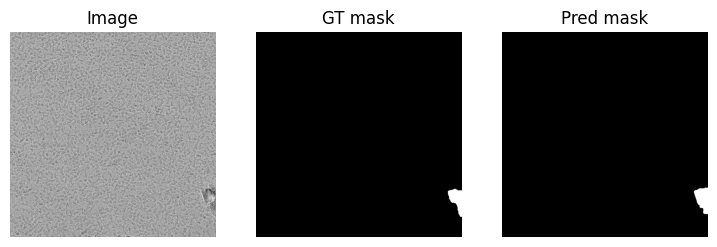

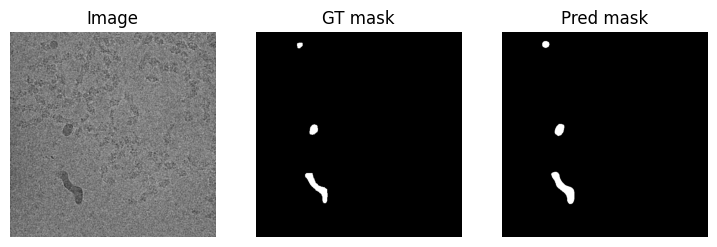

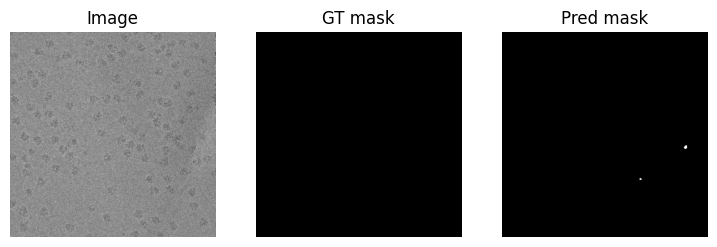

In [12]:
@torch.no_grad()
def visualize_batch(loader, n=3):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    probs = torch.sigmoid(model(x))
    preds = (probs > 0.5).float()

    x = x[:n].cpu().numpy()
    y = y[:n].cpu().numpy()
    p = preds[:n].cpu().numpy()

    for i in range(n):
        plt.figure(figsize=(9,3))
        plt.subplot(1,3,1); plt.title("Image"); plt.imshow(np.transpose(x[i], (1,2,0)), cmap='gray'); plt.axis('off')
        plt.subplot(1,3,2); plt.title("GT mask"); plt.imshow(y[i,0], cmap='gray'); plt.axis('off')
        plt.subplot(1,3,3); plt.title("Pred mask"); plt.imshow(p[i,0], cmap='gray'); plt.axis('off')
        plt.show()

visualize_batch(data_loader, n=3)

**Inference**

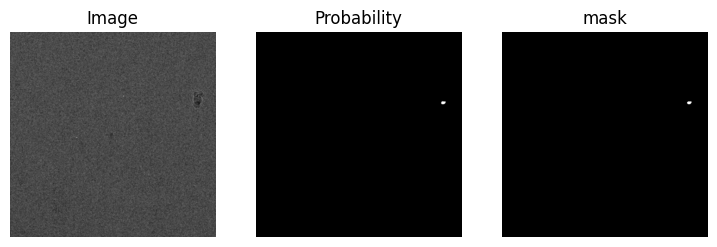

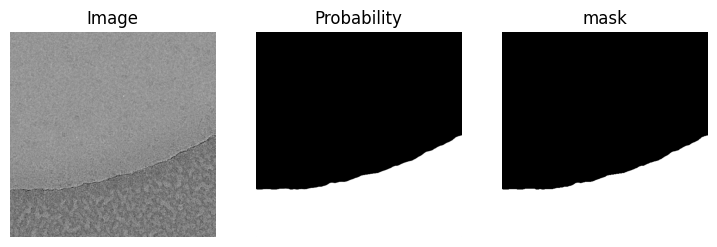

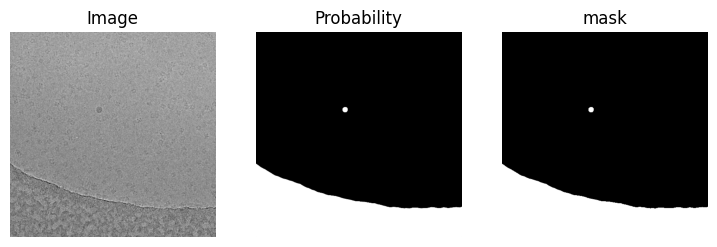

In [14]:
# Minimal inference for U-Net (SMP)
# pip install segmentation-models-pytorch timm (if not already installed)

import os, glob, numpy as np, torch, segmentation_models_pytorch as smp
from skimage.transform import resize
from torch.amp import autocast
from contextlib import nullcontext

# -------- Preprocessing (same as during training) --------
def read_image(fn, out_size=512):
    img = np.load(fn).astype(np.float32)       # (H,W), grayscale
    minv, maxv = float(img.min()), float(img.max())
    if maxv > minv:
        img = (img - minv) / (maxv - minv)    # normalize to [0,1]
    else:
        img = np.zeros_like(img, dtype=np.float32)

    img = resize(img, (out_size, out_size), order=1,
                 anti_aliasing=True, preserve_range=True).astype(np.float32)
    img3 = np.stack([img, img, img], axis=0)  # (3,H,W) to match ImageNet encoders
    return img3

# -------- Device & AMP context --------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_ctx = autocast('cuda') if device.type == 'cuda' else nullcontext()

# -------- Rebuild model EXACTLY as trained and load weights --------
# (Change encoder_name/classes/in_channels if your training used different ones.)
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights=None,   # we'll load our own weights
    in_channels=3,
    classes=1,
).to(device)
state = torch.load(fnModel, map_location=device)
model.load_state_dict(state)
model.eval()

# -------- Single-file prediction helper --------
@torch.no_grad()
def predict_mask(fn, threshold=0.5):
    x = read_image(fn)                     # (3,H,W) float32 in [0,1]
    x = torch.from_numpy(x)[None].to(device)  # (1,3,H,W)
    with amp_ctx:
        logits = model(x)                  # (1,1,H,W)
        prob = torch.sigmoid(logits)[0,0].cpu().numpy().astype(np.float32)  # (H,W)
    mask = (prob >= threshold).astype(np.uint8)
    return x[0, 0].detach().cpu().numpy(), prob, mask

# -------- Run on a list and save outputs --------
file_list = sorted(glob.glob('/content/drive/MyDrive/MicCleaner/*/mics/*.npy'))[15:18]

for fn in file_list:
    img, probability, mask = predict_mask(fn, threshold=0.5)

    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img, cmap='gray'); plt.axis('off')
    plt.subplot(1,3,2); plt.title("Probability"); plt.imshow(probability, cmap='gray'); plt.axis('off')
    plt.subplot(1,3,3); plt.title("mask"); plt.imshow(mask, cmap='gray'); plt.axis('off')
plt.show()